In [3]:
import numpy as np

def read_prof_pressure(filepath):
    pressures = []
    reading = False

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("(pressure"):
                reading = True
                continue

            if reading:
                if line.startswith(")"):
                    break
                pressures.append(float(line))

    return np.array(pressures)

In [4]:
def compute_risk(pressure_array, rupture_pressure):
    p_max = np.max(np.abs(pressure_array))
    risk = min(1.0, p_max / rupture_pressure)
    return risk


In [5]:
import pandas as pd
import glob
import re

rupture_pressure = 355

rows = []

for filepath in glob.glob("cfd/*.prof"):
    # extrai ângulo e velocidade do nome do arquivo
    match = re.search(r"ang_(\d+)_vel_(\d+)", filepath)
    if not match:
        continue

    angle = float(match.group(1))
    velocity = float(match.group(2))

    pressure = read_prof_pressure(filepath)
    risk = compute_risk(pressure, rupture_pressure)

    rows.append({
        "angle": angle,
        "velocity": velocity,
        "risk": risk
    })

df_risk = pd.DataFrame(rows)
df_risk.to_csv("risk_cfd.csv", index=False)


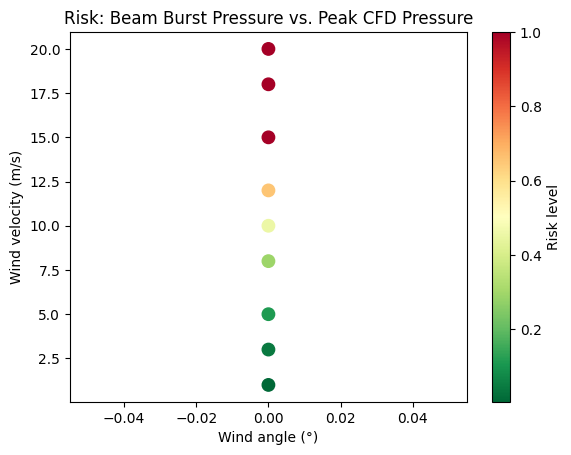

R²: 0.9920190504435413
RMSE: 0.03265535996714363


In [6]:
import matplotlib.pyplot as plt

plt.scatter(
    df_risk["angle"],
    df_risk["velocity"],
    c=df_risk["risk"],
    cmap="RdYlGn_r",
    s=80
)
plt.colorbar(label="Risk level")
plt.xlabel("Wind angle (°)")
plt.ylabel("Wind velocity (m/s)")
plt.title("Risk: Beam Burst Pressure vs. Peak CFD Pressure")
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

X = df_risk[["angle", "velocity"]]
y = df_risk["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.9920190504435413
RMSE: 0.03265535996714363


In [10]:
df_result = pd.read_csv("result_wind_center.csv")

df_pred = df_result[["angle", "velocity"]].copy()
df_pred["risk_pred"] = model.predict(df_pred)
df_pred["risk_pred"] = df_pred["risk_pred"].clip(0, 1)


In [13]:
df_pred.head()

,angle,velocity,risk_pred
0,97.000000,0.166667,0.035976
1,96.000000,0.033333,0.035976
2,87.000000,0.133333,0.035976
3,0.000000,0.000000,0.035976
4,77.238896,0.034235,0.035976


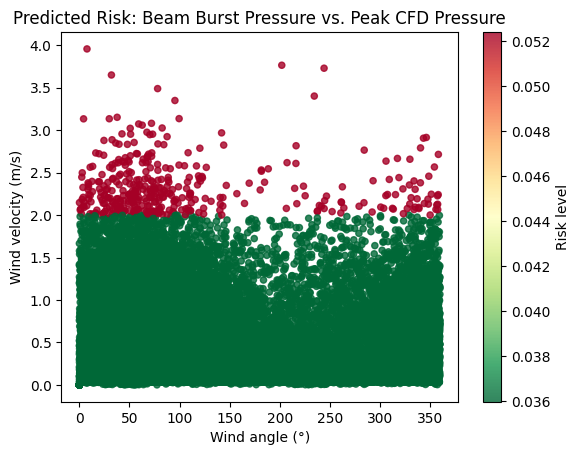

In [11]:
plt.scatter(
    df_pred["angle"],
    df_pred["velocity"],
    c=df_pred["risk_pred"],
    cmap="RdYlGn_r",
    s=20,
    alpha=0.8
)
plt.colorbar(label="Risk level")
plt.xlabel("Wind angle (°)")
plt.ylabel("Wind velocity (m/s)")
plt.title("Predicted Risk: Beam Burst Pressure vs. Peak CFD Pressure")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# supondo df com colunas angle, velocity, risk
angles = np.sort(df_pred["angle"].unique())
velocities = np.sort(df_pred["velocity"].unique())

A, V = np.meshgrid(angles, velocities)

# detect duplicates (optional)
dups = df_pred.duplicated(subset=["velocity", "angle"], keep=False)
if dups.any():
    print(f"Duplicate (velocity,angle) rows: {df_pred[dups].shape[0]} — aggregating with mean")

# replace pivot with pivot_table (aggregates duplicates)
Z = df_pred.pivot_table(
    index="velocity",
    columns="angle",
    values="risk_pred",
    aggfunc="mean"   # choose mean, median, max, etc. as appropriate
).values

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

surf = ax.plot_surface(
    A, V, Z,
    cmap="RdYlGn_r",
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("Ângulo do vento (°)")
ax.set_ylabel("Velocidade do vento")
ax.set_zlabel("Nível de risco")

fig.colorbar(surf, label="Risco")

plt.show()
